# 🌧️ PredRNN++ & UNet++ for Rainfall Prediction (TIME_OUT = 1)

**Mekong Delta Rainfall Prediction using Deep Learning**

## Architecture Overview

### Stage 1: PredRNN++ (Temporal Encoder)

- **Based on:** Official [predrnn-pytorch](https://github.com/thuml/predrnn-pytorch)
- **Key Features:** SpatioTemporalLSTMCell với additive gate computation, forget_bias=1.0, zigzag memory flow
- **Input:** `(B, 30, 24, 35, 35)` - 30 ngày features
- **Output:** `(B, 1, 24, 35, 35)` - 1 ngày predicted features (CHANGED from 14)

### Stage 2: UNet++ (Spatial Decoder)

- **Based on:** Official [UNetPlusPlus](https://github.com/MrGiovanni/UNetPlusPlus)
- **Key Features:** Nested U-Net với dense skip connections
- **Input:** `(B, 1, 24, 35, 35)` - Output từ PredRNN++ (CHANGED from 14)
- **Output:** `(B, 1, 1, 35, 35)` - 1 ngày rainfall prediction (CHANGED from 14)

### Training Flow (theo CS313-data-mining README)

```
Forward: Input → PredRNN++ → UNet++ → Output
Backward: Loss.backward() → Update cả 2 models
```

**⚠️ KHÔNG train song song, forward trực tiếp 2 model rồi backward**


## 1. Setup & Imports


In [1]:
import os
import json
import logging
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


# ==================== CONFIGURATION ====================
class Config:
    """Configuration for PredRNN++ & UNet++ Training

    Follows CS313-data-mining README requirements:
    - Input: (B, time_in=30, C=24, H=35, W=35)
    - Target: (B, time_out=14, C=1, H=35, W=35)
    - Training: Forward both models → single backward
    """

    # Model name & version
    MODEL_NAME = "PredRNNpp_UNetpp_timeout_1"
    VERSION = "v1.0.0"  

    # Paths
    BASE_DIR = Path("../../")
    DATA_DIR = BASE_DIR / "data" / "preprocessed"
    MODEL_DIR = BASE_DIR / "models"
    LOG_DIR = BASE_DIR / "logs"

    # Data parameters (từ CS313-data-mining README)
    TIME_IN = 30            # Input sequence length (days)
    TIME_OUT = 1            # Output sequence length (days) - CHANGED from 14 to 1
    IN_CHANNELS = 24        # Number of input feature channels
    OUT_CHANNELS = 1        # Precipitation output channel
    HEIGHT = 35
    WIDTH = 35

    # Training parameters
    BATCH_SIZE = 4  
    EPOCHS = 10  
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5

    # Early stopping
    PATIENCE = 5  
    MIN_DELTA = 1e-6

    # Device
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # PredRNN++ parameters (based on official implementation)
    PREDRNN_NUM_HIDDEN = [64, 64, 64, 64]   # Hidden dims for each layer
    PREDRNN_NUM_LAYERS = 4
    PREDRNN_FILTER_SIZE = 5                 # Kernel size (official uses 5)
    PREDRNN_STRIDE = 1
    PREDRNN_LAYER_NORM = True

    # UNet++ parameters (based on official implementation)
    UNETPP_FEATURES = [32, 64, 128, 256]
    UNETPP_DEEP_SUPERVISION = False         # Simpler for combined training


config = Config()

# Create directories
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)
config.LOG_DIR.mkdir(parents=True, exist_ok=True)


# ==================== LOGGING SETUP ====================
def setup_logger(name, log_file, level=logging.INFO):
    """Setup logger with file and console handlers"""
    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S"
    )

    handler = logging.FileHandler(log_file)
    handler.setFormatter(formatter)

    console_handler = logging.StreamHandler()
    console_handler.setFormatter(formatter)

    logger = logging.getLogger(name)
    logger.setLevel(level)
    logger.addHandler(handler)
    logger.addHandler(console_handler)

    return logger


# Create timestamp for this run
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_FILE = config.LOG_DIR / f"{config.MODEL_NAME}_{TIMESTAMP}.log"
logger = setup_logger("training", LOG_FILE)

logger.info("=" * 60)
logger.info(f"🚀 Starting {config.MODEL_NAME} {config.VERSION}")
logger.info("   Based on Official Implementations:")
logger.info("   - PredRNN++: github.com/thuml/predrnn-pytorch")
logger.info("   - UNet++: github.com/MrGiovanni/UNetPlusPlus")
logger.info("=" * 60)
logger.info(f"Device: {config.DEVICE}")
if torch.cuda.is_available():
    logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
    logger.info(
        f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB"
    )
logger.info(f"Log file: {LOG_FILE}")
logger.info("=" * 60)


2025-12-06 23:20:34 | INFO | ============================================================
2025-12-06 23:20:34 | INFO | 🚀 Starting PredRNNpp_UNetpp_timeout_1 v1.0.0
2025-12-06 23:20:34 | INFO |    Based on Official Implementations:
2025-12-06 23:20:34 | INFO |    - PredRNN++: github.com/thuml/predrnn-pytorch
2025-12-06 23:20:34 | INFO |    - UNet++: github.com/MrGiovanni/UNetPlusPlus
2025-12-06 23:20:34 | INFO | ============================================================
2025-12-06 23:20:34 | INFO | Device: cuda
2025-12-06 23:20:34 | INFO | 🚀 Starting PredRNNpp_UNetpp_timeout_1 v1.0.0
2025-12-06 23:20:34 | INFO |    Based on Official Implementations:
2025-12-06 23:20:34 | INFO |    - PredRNN++: github.com/thuml/predrnn-pytorch
2025-12-06 23:20:34 | INFO |    - UNet++: github.com/MrGiovanni/UNetPlusPlus
2025-12-06 23:20:34 | INFO | ============================================================
2025-12-06 23:20:34 | INFO | Device: cuda
2025-12-06 23:20:34 | INFO | GPU: NVIDIA GeForce RTX 5

## 2. Dataset Classes (Self-contained)

Copy từ `src/data_module.py` để notebook hoàn toàn self-contained.

**Data Flow:**

- Input: `(B, 30, 24, 35, 35)` - 30 ngày × 24 features × 35×35 spatial
- Target: `(B, 14, 24, 35, 35)` - 14 ngày × 24 features (extract channel 0 for precipitation)


In [2]:
# ==================== DATASET CLASSES (SELF-CONTAINED) ====================
# Copy từ src/data_module.py để notebook hoàn toàn self-contained


class FolderTimeSeriesDataset(Dataset):
    """
    PyTorch Dataset load từng file .npy từ folder với sliding window.

    Structure:
        data/preprocessed/train/features/0000.npy, 0001.npy, ...
        data/preprocessed/train/target/0000.npy, 0001.npy, ...

    Input: [time_in, 24, H, W] - 24 feature channels
    Target: [time_out, 1, H, W] - 1 precipitation channel
    """

    def __init__(self, root_dir, time_in=30, time_out=14):
        self.feature_dir = os.path.join(root_dir, "features")
        self.target_dir = os.path.join(
            root_dir, "target"
        )  # Correct: separate target folder

        self.feature_files = sorted(os.listdir(self.feature_dir))
        self.target_files = sorted(os.listdir(self.target_dir))
        assert len(self.feature_files) == len(self.target_files), "features != target"

        self.time_in = time_in
        self.time_out = time_out

        # Tạo danh sách index cho sliding window
        self.sample_indices = []
        total_timesteps = len(self.feature_files)
        for i in range(total_timesteps - time_in - time_out + 1):
            self.sample_indices.append(i)

    def __len__(self):
        return len(self.sample_indices)

    def __getitem__(self, idx):
        start_idx = self.sample_indices[idx]

        # Load input sequence (features - 24 channels)
        X_list = []
        for i in range(start_idx, start_idx + self.time_in):
            feat = np.load(
                os.path.join(self.feature_dir, self.feature_files[i])
            )  # [H,W,C=24]
            feat = np.transpose(feat, (2, 0, 1))  # [C=24,H,W]
            X_list.append(feat)
        X = np.stack(X_list, axis=0)  # [time_in, 24, H, W]

        # Load target sequence (precipitation - 1 channel)
        Y_list = []
        for i in range(
            start_idx + self.time_in, start_idx + self.time_in + self.time_out
        ):
            targ = np.load(
                os.path.join(self.target_dir, self.target_files[i])
            )  # [H,W,C=1]
            targ = np.transpose(targ, (2, 0, 1))  # [C=1,H,W]
            Y_list.append(targ)
        Y = np.stack(Y_list, axis=0)  # [time_out, 1, H, W]

        return torch.FloatTensor(X), torch.FloatTensor(Y)


def get_dataloaders(
    path,
    time_in=30,
    time_out=14,
    batch_size=8,
    num_workers=4,
    pin_memory=True,
    drop_last=False,
):
    """
    Create dataloaders for training.

    Returns:
        dict with 'train', 'val', 'test' DataLoaders
    """
    result = {}

    for split in ["train", "val", "test"]:
        split_dir = os.path.join(path, split)

        # FolderTimeSeriesDataset (sliding window)
        dataset = FolderTimeSeriesDataset(
            root_dir=split_dir, time_in=time_in, time_out=time_out
        )

        result[split] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split == "train"),  # Shuffle only for training
            num_workers=num_workers,
            pin_memory=pin_memory,
            drop_last=drop_last,
        )

    return result


logger.info("✅ Dataset classes defined (self-contained)")


2025-12-06 23:20:34 | INFO | ✅ Dataset classes defined (self-contained)


In [3]:
# ==================== LOAD DATA ====================
logger.info("📂 Loading datasets...")

# Get dataloaders
dataloaders = get_dataloaders(
    path=str(config.DATA_DIR),
    time_in=config.TIME_IN,
    time_out=config.TIME_OUT,
    batch_size=config.BATCH_SIZE,
    num_workers=4,
    pin_memory=True,
    drop_last=False,
)

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Verify data shapes
sample_x, sample_y = next(iter(train_loader))
logger.info(f"✅ Data loaded successfully!")
logger.info(f"   Train batches: {len(train_loader)}")
logger.info(f"   Val batches: {len(val_loader)}")
logger.info(f"   Test batches: {len(test_loader)}")
logger.info(f"   Input shape: {list(sample_x.shape)}")  # [B, 30, 24, 35, 35]
logger.info(f"   Target shape: {list(sample_y.shape)}")  # [B, 14, 1, 35, 35]

print(f"\n📊 Data Summary (theo CS313-data-mining README):")
print(
    f"   Input:  (B, {config.TIME_IN}, {config.IN_CHANNELS}, {config.HEIGHT}, {config.WIDTH})"
)
print(
    f"   Target: (B, {config.TIME_OUT}, {config.OUT_CHANNELS}, {config.HEIGHT}, {config.WIDTH})"
)
print(f"   Target has {config.OUT_CHANNELS} channel (precipitation only)")


2025-12-06 23:20:34 | INFO | 📂 Loading datasets...
2025-12-06 23:20:34 | INFO | ✅ Data loaded successfully!
2025-12-06 23:20:34 | INFO |    Train batches: 449
2025-12-06 23:20:34 | INFO |    Val batches: 38
2025-12-06 23:20:34 | INFO |    Test batches: 39
2025-12-06 23:20:34 | INFO |    Input shape: [4, 30, 24, 35, 35]
2025-12-06 23:20:34 | INFO |    Target shape: [4, 1, 1, 35, 35]



📊 Data Summary (theo CS313-data-mining README):
   Input:  (B, 30, 24, 35, 35)
   Target: (B, 1, 1, 35, 35)
   Target has 1 channel (precipitation only)


## 3. PredRNN++ Model (Official Implementation)

Implementation based on **official predrnn-pytorch** repository.

### Key Components (từ official SpatioTemporalLSTMCell.py):

1. **SpatioTemporalLSTMCell:**

   - `conv_x`: Input convolution → 7 gates (i, f, g, i', f', g', o)
   - `conv_h`: Hidden state convolution → 4 gates (i, f, g, o)
   - `conv_m`: Memory convolution → 3 gates (i', f', g')
   - **Additive gate computation:** `i_t = sigmoid(i_x + i_h)` (NOT concat!)
   - **Forget bias:** `_forget_bias = 1.0`

2. **Memory Flow (Zigzag):**

   - Memory `M` flows từ layer cuối của timestep trước đến layer đầu của timestep hiện tại
   - Kết hợp temporal (C) và spatial (M) memory

3. **Output Gate:**
   - `o_t = sigmoid(o_x + o_h + conv_o([c_new, m_new]))`


In [4]:
# ==================== PredRNN++ OFFICIAL IMPLEMENTATION ====================
# EXACT COPY from: https://github.com/thuml/predrnn-pytorch/blob/master/core/layers/SpatioTemporalLSTMCell.py
# NO MODIFICATIONS - keeping official structure 100%


class SpatioTemporalLSTMCell(nn.Module):
    """
    Spatio-Temporal LSTM Cell - EXACT Official Implementation

    NOTE: Official uses only 'width' parameter (assumes square input).
    CS313 data is 35x35 (square), so this is compatible.
    """

    def __init__(self, in_channel, num_hidden, width, filter_size, stride, layer_norm):
        super(SpatioTemporalLSTMCell, self).__init__()

        self.num_hidden = num_hidden
        self.padding = filter_size // 2
        self._forget_bias = 1.0
        if layer_norm:
            self.conv_x = nn.Sequential(
                nn.Conv2d(
                    in_channel,
                    num_hidden * 7,
                    kernel_size=filter_size,
                    stride=stride,
                    padding=self.padding,
                    bias=False,
                ),
                nn.LayerNorm([num_hidden * 7, width, width]),
            )
            self.conv_h = nn.Sequential(
                nn.Conv2d(
                    num_hidden,
                    num_hidden * 4,
                    kernel_size=filter_size,
                    stride=stride,
                    padding=self.padding,
                    bias=False,
                ),
                nn.LayerNorm([num_hidden * 4, width, width]),
            )
            self.conv_m = nn.Sequential(
                nn.Conv2d(
                    num_hidden,
                    num_hidden * 3,
                    kernel_size=filter_size,
                    stride=stride,
                    padding=self.padding,
                    bias=False,
                ),
                nn.LayerNorm([num_hidden * 3, width, width]),
            )
            self.conv_o = nn.Sequential(
                nn.Conv2d(
                    num_hidden * 2,
                    num_hidden,
                    kernel_size=filter_size,
                    stride=stride,
                    padding=self.padding,
                    bias=False,
                ),
                nn.LayerNorm([num_hidden, width, width]),
            )
        else:
            self.conv_x = nn.Sequential(
                nn.Conv2d(
                    in_channel,
                    num_hidden * 7,
                    kernel_size=filter_size,
                    stride=stride,
                    padding=self.padding,
                    bias=False,
                ),
            )
            self.conv_h = nn.Sequential(
                nn.Conv2d(
                    num_hidden,
                    num_hidden * 4,
                    kernel_size=filter_size,
                    stride=stride,
                    padding=self.padding,
                    bias=False,
                ),
            )
            self.conv_m = nn.Sequential(
                nn.Conv2d(
                    num_hidden,
                    num_hidden * 3,
                    kernel_size=filter_size,
                    stride=stride,
                    padding=self.padding,
                    bias=False,
                ),
            )
            self.conv_o = nn.Sequential(
                nn.Conv2d(
                    num_hidden * 2,
                    num_hidden,
                    kernel_size=filter_size,
                    stride=stride,
                    padding=self.padding,
                    bias=False,
                ),
            )
        self.conv_last = nn.Conv2d(
            num_hidden * 2, num_hidden, kernel_size=1, stride=1, padding=0, bias=False
        )

    def forward(self, x_t, h_t, c_t, m_t):
        x_concat = self.conv_x(x_t)
        h_concat = self.conv_h(h_t)
        m_concat = self.conv_m(m_t)
        i_x, f_x, g_x, i_x_prime, f_x_prime, g_x_prime, o_x = torch.split(
            x_concat, self.num_hidden, dim=1
        )
        i_h, f_h, g_h, o_h = torch.split(h_concat, self.num_hidden, dim=1)
        i_m, f_m, g_m = torch.split(m_concat, self.num_hidden, dim=1)

        i_t = torch.sigmoid(i_x + i_h)
        f_t = torch.sigmoid(f_x + f_h + self._forget_bias)
        g_t = torch.tanh(g_x + g_h)

        c_new = f_t * c_t + i_t * g_t

        i_t_prime = torch.sigmoid(i_x_prime + i_m)
        f_t_prime = torch.sigmoid(f_x_prime + f_m + self._forget_bias)
        g_t_prime = torch.tanh(g_x_prime + g_m)

        m_new = f_t_prime * m_t + i_t_prime * g_t_prime

        mem = torch.cat((c_new, m_new), 1)
        o_t = torch.sigmoid(o_x + o_h + self.conv_o(mem))
        h_new = o_t * torch.tanh(self.conv_last(mem))

        return h_new, c_new, m_new


class PredRNNPlusPlus(nn.Module):
    """
    PredRNN++ Model - Official Architecture

    Based on: https://github.com/thuml/predrnn-pytorch/blob/master/core/models/predrnn.py

    Key features:
    1. Stack of SpatioTemporalLSTMCells
    2. Zigzag memory flow: M flows from last layer of t-1 to first layer of t
    3. Scheduled sampling for teacher forcing (optional during inference)

    NOTE: Uses only 'width' for SpatioTemporalLSTMCell (official assumes square input).
    CS313 data is 35x35 (square), so height==width is ensured.

    Input: (B, T_in, C, H, W)
    Output: (B, T_out, C, H, W)
    """

    def __init__(
        self,
        num_layers,
        num_hidden,
        in_channel,
        width,
        filter_size=5,
        stride=1,
        layer_norm=True,
        output_channel=None,
    ):
        super(PredRNNPlusPlus, self).__init__()

        self.num_layers = num_layers
        self.num_hidden = num_hidden  # List of hidden dims per layer
        self.in_channel = in_channel
        self.width = width
        self.output_channel = output_channel if output_channel else in_channel

        # Build cell stack (official structure)
        cell_list = []
        for i in range(num_layers):
            in_ch = in_channel if i == 0 else num_hidden[i - 1]
            cell_list.append(
                SpatioTemporalLSTMCell(
                    in_channel=in_ch,
                    num_hidden=num_hidden[i],
                    width=width,
                    filter_size=filter_size,
                    stride=stride,
                    layer_norm=layer_norm,
                )
            )
        self.cell_list = nn.ModuleList(cell_list)

        # Output projection
        self.conv_last = nn.Conv2d(
            num_hidden[-1],
            self.output_channel,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False,
        )

    def forward(self, frames, future_length=14, teacher_forcing_ratio=0.0):
        """
        Args:
            frames: Input tensor (B, T_in, C, H, W)
            future_length: Number of future frames to predict
            teacher_forcing_ratio: Probability of using ground truth as input (0 for inference)

        Returns:
            predictions: (B, future_length, C, H, W)
        """
        B, T_in, C, H, W = frames.shape
        device = frames.device

        # Initialize hidden states
        h_t = []
        c_t = []
        for i in range(self.num_layers):
            zeros = torch.zeros(B, self.num_hidden[i], H, W, device=device)
            h_t.append(zeros)
            c_t.append(zeros)

        # Initialize spatiotemporal memory (shared, zigzag flow)
        memory = torch.zeros(B, self.num_hidden[0], H, W, device=device)

        # ==================== Encoding Phase ====================
        # Process input sequence to build up hidden states
        for t in range(T_in):
            net = frames[:, t]  # (B, C, H, W)

            # Forward through all layers
            h_t[0], c_t[0], memory = self.cell_list[0](net, h_t[0], c_t[0], memory)

            for i in range(1, self.num_layers):
                # Input to layer i is output of layer i-1
                h_t[i], c_t[i], memory = self.cell_list[i](
                    h_t[i - 1], h_t[i], c_t[i], memory
                )

        # ==================== Prediction Phase ====================
        # Generate future frames autoregressively
        predictions = []

        # First prediction input is last generated frame or projection of last hidden state
        x_gen = self.conv_last(h_t[-1])  # (B, C, H, W)

        for t in range(future_length):
            # Forward through all layers
            h_t[0], c_t[0], memory = self.cell_list[0](x_gen, h_t[0], c_t[0], memory)

            for i in range(1, self.num_layers):
                h_t[i], c_t[i], memory = self.cell_list[i](
                    h_t[i - 1], h_t[i], c_t[i], memory
                )

            # Generate prediction for this timestep
            x_gen = self.conv_last(h_t[-1])
            predictions.append(x_gen)

        # Stack predictions: (B, T_out, C, H, W)
        predictions = torch.stack(predictions, dim=1)

        return predictions


logger.info("✅ PredRNN++ (Official) model defined")
logger.info("   - SpatioTemporalLSTMCell với additive gates")
logger.info("   - forget_bias = 1.0")
logger.info("   - Zigzag memory flow")


2025-12-06 23:20:34 | INFO | ✅ PredRNN++ (Official) model defined
2025-12-06 23:20:34 | INFO |    - SpatioTemporalLSTMCell với additive gates
2025-12-06 23:20:34 | INFO |    - forget_bias = 1.0
2025-12-06 23:20:34 | INFO |    - Zigzag memory flow
2025-12-06 23:20:34 | INFO |    - SpatioTemporalLSTMCell với additive gates
2025-12-06 23:20:34 | INFO |    - forget_bias = 1.0
2025-12-06 23:20:34 | INFO |    - Zigzag memory flow


## 4. UNet++ Model (Official Implementation)

Implementation based on **official UNetPlusPlus** repository.

### Key Components (từ official implementation):

1. **Nested Skip Connections:**

   - `X[i,j] = concat(X[i,0], ..., X[i,j-1], Up(X[i+1,j-1]))`
   - Dense connections giữa encoder và decoder paths

2. **Architecture:**

   ```
   X0,0 → X1,0 → X2,0 → X3,0 → X4,0 (Encoder)
          ↘     ↘     ↘     ↘
         X0,1 → X1,1 → X2,1 → X3,1
                ↘     ↘     ↘
               X0,2 → X1,2 → X2,2
                      ↘     ↘
                     X0,3 → X1,3
                            ↘
                           X0,4 (Output)
   ```

3. **Deep Supervision (optional):**
   - Multi-scale outputs from X0,1 đến X0,4
   - Average predictions for final output

### Adaptation for Rainfall Prediction:

- **Input:** `(B, T, C, H, W)` - Sequence of feature maps
- **Output:** `(B, T, 1, H, W)` - Sequence of precipitation maps
- Process each timestep independently through UNet++


In [5]:
# ==================== UNet++ OFFICIAL IMPLEMENTATION ====================
# Based on: https://github.com/MrGiovanni/UNetPlusPlus


class ConvBlock(nn.Module):
    """Standard Convolution Block: Conv -> BN -> ReLU -> Conv -> BN -> ReLU"""

    def __init__(self, in_channels, out_channels, kernel_size=3):
        super(ConvBlock, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size, padding=padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels, out_channels, kernel_size, padding=padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNetPlusPlusCore(nn.Module):
    """
    UNet++ (Nested U-Net) - Official Architecture

    Based on: https://github.com/MrGiovanni/UNetPlusPlus

    Key features:
    1. Dense skip connections: X[i,j] = f(concat(X[i,0:j], Up(X[i+1,j-1])))
    2. Optional deep supervision
    3. Reduces semantic gap between encoder and decoder

    Single frame: Input (B, C, H, W) -> Output (B, out_ch, H, W)
    """

    def __init__(
        self,
        in_channels=24,
        out_channels=1,
        features=[32, 64, 128, 256],
        deep_supervision=False,
    ):
        super(UNetPlusPlusCore, self).__init__()

        self.deep_supervision = deep_supervision
        self.pool = nn.MaxPool2d(2, 2)

        # ==================== Encoder (Backbone) ====================
        # X0,0
        self.conv0_0 = ConvBlock(in_channels, features[0])
        # X1,0
        self.conv1_0 = ConvBlock(features[0], features[1])
        # X2,0
        self.conv2_0 = ConvBlock(features[1], features[2])
        # X3,0
        self.conv3_0 = ConvBlock(features[2], features[3])
        # X4,0 (Bottleneck)
        self.conv4_0 = ConvBlock(features[3], features[3] * 2)

        # ==================== Decoder with Nested Skip Connections ====================
        # Upsampling layers
        self.up1_0 = nn.ConvTranspose2d(features[1], features[0], 2, stride=2)
        self.up2_0 = nn.ConvTranspose2d(features[2], features[1], 2, stride=2)
        self.up3_0 = nn.ConvTranspose2d(features[3], features[2], 2, stride=2)
        self.up4_0 = nn.ConvTranspose2d(features[3] * 2, features[3], 2, stride=2)

        self.up1_1 = nn.ConvTranspose2d(features[1], features[0], 2, stride=2)
        self.up2_1 = nn.ConvTranspose2d(features[2], features[1], 2, stride=2)
        self.up3_1 = nn.ConvTranspose2d(features[3], features[2], 2, stride=2)

        self.up1_2 = nn.ConvTranspose2d(features[1], features[0], 2, stride=2)
        self.up2_2 = nn.ConvTranspose2d(features[2], features[1], 2, stride=2)

        self.up1_3 = nn.ConvTranspose2d(features[1], features[0], 2, stride=2)

        # Dense blocks - Column 1
        # X0,1: concat(X0,0, Up(X1,0))
        self.conv0_1 = ConvBlock(features[0] + features[0], features[0])
        # X1,1: concat(X1,0, Up(X2,0))
        self.conv1_1 = ConvBlock(features[1] + features[1], features[1])
        # X2,1: concat(X2,0, Up(X3,0))
        self.conv2_1 = ConvBlock(features[2] + features[2], features[2])
        # X3,1: concat(X3,0, Up(X4,0))
        self.conv3_1 = ConvBlock(features[3] + features[3], features[3])

        # Dense blocks - Column 2
        # X0,2: concat(X0,0, X0,1, Up(X1,1))
        self.conv0_2 = ConvBlock(features[0] * 2 + features[0], features[0])
        # X1,2: concat(X1,0, X1,1, Up(X2,1))
        self.conv1_2 = ConvBlock(features[1] * 2 + features[1], features[1])
        # X2,2: concat(X2,0, X2,1, Up(X3,1))
        self.conv2_2 = ConvBlock(features[2] * 2 + features[2], features[2])

        # Dense blocks - Column 3
        # X0,3: concat(X0,0, X0,1, X0,2, Up(X1,2))
        self.conv0_3 = ConvBlock(features[0] * 3 + features[0], features[0])
        # X1,3: concat(X1,0, X1,1, X1,2, Up(X2,2))
        self.conv1_3 = ConvBlock(features[1] * 3 + features[1], features[1])

        # Dense blocks - Column 4
        # X0,4: concat(X0,0, X0,1, X0,2, X0,3, Up(X1,3))
        self.conv0_4 = ConvBlock(features[0] * 4 + features[0], features[0])

        # ==================== Output ====================
        if deep_supervision:
            self.final1 = nn.Conv2d(features[0], out_channels, 1)
            self.final2 = nn.Conv2d(features[0], out_channels, 1)
            self.final3 = nn.Conv2d(features[0], out_channels, 1)
            self.final4 = nn.Conv2d(features[0], out_channels, 1)
        else:
            self.final = nn.Conv2d(features[0], out_channels, 1)

    def _match_size(self, x, target):
        """Match spatial dimensions via bilinear interpolation"""
        if x.shape[2:] != target.shape[2:]:
            x = nn.functional.interpolate(
                x, size=target.shape[2:], mode="bilinear", align_corners=True
            )
        return x

    def forward(self, x):
        """
        Args:
            x: Input tensor (B, C, H, W)
        Returns:
            output: (B, out_channels, H, W)
        """
        # ==================== Encoder ====================
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))

        # ==================== Decoder Column 1 ====================
        x0_1 = self.conv0_1(
            torch.cat([x0_0, self._match_size(self.up1_0(x1_0), x0_0)], dim=1)
        )
        x1_1 = self.conv1_1(
            torch.cat([x1_0, self._match_size(self.up2_0(x2_0), x1_0)], dim=1)
        )
        x2_1 = self.conv2_1(
            torch.cat([x2_0, self._match_size(self.up3_0(x3_0), x2_0)], dim=1)
        )
        x3_1 = self.conv3_1(
            torch.cat([x3_0, self._match_size(self.up4_0(x4_0), x3_0)], dim=1)
        )

        # ==================== Decoder Column 2 ====================
        x0_2 = self.conv0_2(
            torch.cat([x0_0, x0_1, self._match_size(self.up1_1(x1_1), x0_0)], dim=1)
        )
        x1_2 = self.conv1_2(
            torch.cat([x1_0, x1_1, self._match_size(self.up2_1(x2_1), x1_0)], dim=1)
        )
        x2_2 = self.conv2_2(
            torch.cat([x2_0, x2_1, self._match_size(self.up3_1(x3_1), x2_0)], dim=1)
        )

        # ==================== Decoder Column 3 ====================
        x0_3 = self.conv0_3(
            torch.cat(
                [x0_0, x0_1, x0_2, self._match_size(self.up1_2(x1_2), x0_0)], dim=1
            )
        )
        x1_3 = self.conv1_3(
            torch.cat(
                [x1_0, x1_1, x1_2, self._match_size(self.up2_2(x2_2), x1_0)], dim=1
            )
        )

        # ==================== Decoder Column 4 ====================
        x0_4 = self.conv0_4(
            torch.cat(
                [x0_0, x0_1, x0_2, x0_3, self._match_size(self.up1_3(x1_3), x0_0)],
                dim=1,
            )
        )

        # ==================== Output ====================
        if self.deep_supervision and self.training:
            out1 = self.final1(x0_1)
            out2 = self.final2(x0_2)
            out3 = self.final3(x0_3)
            out4 = self.final4(x0_4)
            return (out1 + out2 + out3 + out4) / 4  # Average for training stability
        else:
            return self.final(x0_4) if hasattr(self, "final") else self.final4(x0_4)


class UNetPlusPlus(nn.Module):
    """
    UNet++ Wrapper for Sequence Processing

    Theo CS313-data-mining README (updated):
    - Model 2 (UNet++) core:
        - Input: (B, C, H, W) - single frame
        - Output: (B, 1, H, W) - single frame

    Wrapper này xử lý sequence bằng cách:
    1. Flatten (B, T, C, H, W) → (B*T, C, H, W)
    2. Forward qua UNet++ core cho từng frame độc lập
    3. Reshape (B*T, 1, H, W) → (B, T, 1, H, W)
    """

    def __init__(
        self,
        in_channels=24,
        out_channels=1,
        features=[32, 64, 128, 256],
        deep_supervision=False,
    ):
        super(UNetPlusPlus, self).__init__()

        self.unet = UNetPlusPlusCore(
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            deep_supervision=deep_supervision,
        )

    def forward(self, x):
        """
        Args:
            x: Input tensor (B, T, C, H, W) - sequence from PredRNN++

        Returns:
            output: (B, T, 1, H, W) - processed sequence

        Internal flow (per frame):
            (B, C, H, W) → UNet++ → (B, 1, H, W)
        """
        B, T, C, H, W = x.shape

        # Flatten sequence: (B, T, C, H, W) → (B*T, C, H, W)
        x_flat = x.view(B * T, C, H, W)

        # Forward through UNet++ (each frame independently)
        # (B*T, C, H, W) → (B*T, 1, H, W)
        out_flat = self.unet(x_flat)

        # Reshape back to sequence: (B*T, 1, H, W) → (B, T, 1, H, W)
        out_ch = out_flat.shape[1]
        output = out_flat.view(B, T, out_ch, H, W)

        return output


logger.info("✅ UNet++ (Official) model defined")
logger.info(
    "   - Nested skip connections: X[i,j] = f(concat(X[i,0:j], Up(X[i+1,j-1])))"
)
logger.info("   - Core: (B, C, H, W) → (B, 1, H, W) per frame")
logger.info("   - Wrapper: (B, T, C, H, W) → (B, T, 1, H, W) for sequence")


2025-12-06 23:20:34 | INFO | ✅ UNet++ (Official) model defined
2025-12-06 23:20:34 | INFO |    - Nested skip connections: X[i,j] = f(concat(X[i,0:j], Up(X[i+1,j-1])))
2025-12-06 23:20:34 | INFO |    - Core: (B, C, H, W) → (B, 1, H, W) per frame
2025-12-06 23:20:34 | INFO |    - Wrapper: (B, T, C, H, W) → (B, T, 1, H, W) for sequence
2025-12-06 23:20:34 | INFO |    - Nested skip connections: X[i,j] = f(concat(X[i,0:j], Up(X[i+1,j-1])))
2025-12-06 23:20:34 | INFO |    - Core: (B, C, H, W) → (B, 1, H, W) per frame
2025-12-06 23:20:34 | INFO |    - Wrapper: (B, T, C, H, W) → (B, T, 1, H, W) for sequence


## 5. Combined Model & Training Pipeline

### Training Flow (theo CS313-data-mining README - UPDATED):

**Model 1 (PredRNN++):**

- Input: `(B, time_in, C, H, W)` = `(B, 30, 24, 35, 35)`
- Output: `(B, time_out, C, H, W)` = `(B, 14, 24, 35, 35)`

**Model 2 (UNet++) - per frame:**

- Input: `(B, C, H, W)` = `(B, 24, 35, 35)`
- Output: `(B, 1, H, W)` = `(B, 1, 35, 35)`

```
Combined Pipeline:
Input → PredRNN++ → [14 frames] → UNet++ (per frame) → Output
(B,30,24,H,W) → (B,14,24,H,W) → (B,14,1,H,W)

Backward: MSE_Loss(Output, Target).backward()
          → Update cả PredRNN++ và UNet++ trong một backward pass
```

**⚠️ QUAN TRỌNG:** Forward trực tiếp 2 model rồi backward, KHÔNG train song song!


In [6]:
# ==================== COMBINED MODEL ====================


class PredRNNpp_UNetpp(nn.Module):
    """
    Combined PredRNN++ and UNet++ Model

    Training Flow (theo CS313-data-mining README - UPDATED):

    Model 1 (PredRNN++):
        - Input: (B, time_in, C, H, W) = (B, 30, 24, 35, 35)
        - Output: (B, time_out, C, H, W) = (B, 14, 24, 35, 35)

    Model 2 (UNet++) - xử lý từng frame:
        - Input: (B, C, H, W) = (B, 24, 35, 35)
        - Output: (B, 1, H, W) = (B, 1, 35, 35)

    Combined flow:
        Input → PredRNN++ → [14 frames] → UNet++ (per frame) → Output
        (B,30,24,H,W) → (B,14,24,H,W) → (B,14,1,H,W)

    Single backward pass để update cả 2 models.
    """

    def __init__(self, config):
        super(PredRNNpp_UNetpp, self).__init__()

        # Stage 1: PredRNN++ (Temporal Encoder)
        # NOTE: Official PredRNN uses only 'width' (assumes square input)
        # CS313 data is 35x35 (square), so we use WIDTH only
        self.predrnn = PredRNNPlusPlus(
            num_layers=config.PREDRNN_NUM_LAYERS,
            num_hidden=config.PREDRNN_NUM_HIDDEN,
            in_channel=config.IN_CHANNELS,
            width=config.WIDTH,  # Official uses only width (square input)
            filter_size=config.PREDRNN_FILTER_SIZE,
            stride=config.PREDRNN_STRIDE,
            layer_norm=config.PREDRNN_LAYER_NORM,
            output_channel=config.IN_CHANNELS,  # Output same channels as input
        )

        # Stage 2: UNet++ (Spatial Decoder - per frame)
        # Core: (B, C, H, W) → (B, 1, H, W)
        # Wrapper handles sequence: (B, T, C, H, W) → (B, T, 1, H, W)
        self.unetpp = UNetPlusPlus(
            in_channels=config.IN_CHANNELS,
            out_channels=config.OUT_CHANNELS,
            features=config.UNETPP_FEATURES,
            deep_supervision=config.UNETPP_DEEP_SUPERVISION,
        )

        self.time_out = config.TIME_OUT

    def forward(self, x):
        """
        Args:
            x: Input tensor (B, T_in, C, H, W) = (B, 30, 24, 35, 35)

        Returns:
            output: (B, T_out, 1, H, W) = (B, 14, 1, 35, 35)
        """
        # Stage 1: PredRNN++ - Temporal prediction
        # (B, 30, 24, H, W) → (B, 14, 24, H, W)
        temporal_features = self.predrnn(x, future_length=self.time_out)

        # Stage 2: UNet++ - Spatial decoding (per frame)
        # (B, 14, 24, H, W) → (B, 14, 1, H, W)
        # Internally: each frame (B, 24, H, W) → (B, 1, H, W)
        output = self.unetpp(temporal_features)

        return output

    def get_intermediate_output(self, x):
        """Get both intermediate and final outputs for analysis"""
        temporal_features = self.predrnn(x, future_length=self.time_out)
        output = self.unetpp(temporal_features)
        return temporal_features, output


# ==================== TRAINING UTILITIES ====================


class ModelCheckpoint:
    """Save model checkpoints with versioning"""

    def __init__(self, model_dir, model_name, version):
        self.model_dir = Path(model_dir)
        self.model_name = model_name
        self.version = version
        self.best_loss = float("inf")

    def save(self, model, optimizer, scheduler, epoch, loss, history, is_best=False):
        checkpoint = {
            "model_name": self.model_name,
            "version": self.version,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
            "loss": loss,
            "history": history,
            "timestamp": datetime.now().isoformat(),
        }

        # Save latest
        latest_path = self.model_dir / f"{self.model_name}_{self.version}_latest.pth"
        torch.save(checkpoint, latest_path)

        # Save best
        if is_best:
            best_path = self.model_dir / f"{self.model_name}_{self.version}_best.pth"
            torch.save(checkpoint, best_path)
            self.best_loss = loss
            logger.info(f"💾 Saved best model: {best_path}")

        return latest_path

    def load(self, model, optimizer=None, scheduler=None, load_best=True):
        if load_best:
            path = self.model_dir / f"{self.model_name}_{self.version}_best.pth"
        else:
            path = self.model_dir / f"{self.model_name}_{self.version}_latest.pth"

        if path.exists():
            checkpoint = torch.load(path, map_location=config.DEVICE)
            model.load_state_dict(checkpoint["model_state_dict"])
            if optimizer and "optimizer_state_dict" in checkpoint:
                optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            if scheduler and checkpoint.get("scheduler_state_dict"):
                scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            logger.info(f"📂 Loaded model from {path}")
            return checkpoint
        else:
            logger.warning(f"No checkpoint found at {path}")
            return None


class TrainingLogger:
    """Log training metrics to JSON file"""

    def __init__(self, log_dir, model_name, version):
        self.log_path = Path(log_dir) / f"{model_name}_{version}_metrics.json"
        self.metrics = {
            "model_name": model_name,
            "version": version,
            "config": {},
            "training_history": [],
            "best_metrics": {},
        }

    def log_config(self, config_dict):
        self.metrics["config"] = config_dict
        self._save()

    def log_epoch(self, epoch, train_loss, train_mae, val_loss, val_mae, lr):
        self.metrics["training_history"].append(
            {
                "epoch": epoch,
                "train_loss": float(train_loss),
                "train_mae": float(train_mae),
                "val_loss": float(val_loss),
                "val_mae": float(val_mae),
                "learning_rate": float(lr),
                "timestamp": datetime.now().isoformat(),
            }
        )
        self._save()

    def log_best(self, epoch, val_loss, val_mae):
        self.metrics["best_metrics"] = {
            "epoch": epoch,
            "val_loss": float(val_loss),
            "val_mae": float(val_mae),
            "timestamp": datetime.now().isoformat(),
        }
        self._save()

    def _save(self):
        with open(self.log_path, "w") as f:
            json.dump(self.metrics, f, indent=2)


def train_combined_model(
    model, train_loader, val_loader, config, checkpoint, metrics_logger
):
    """
    Train combined PredRNN++ & UNet++ model

    Key points (theo CS313-data-mining README):
    1. Forward cả 2 model liên tiếp
    2. Tính loss với precipitation target
    3. Single backward pass cập nhật cả 2 models
    """

    # Loss function
    criterion = nn.MSELoss()

    # Optimizer for BOTH models (joint training)
    optimizer = optim.AdamW(
        model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY
    )

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    # Training state
    best_val_loss = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "train_mae": [], "val_loss": [], "val_mae": []}

    logger.info("=" * 60)
    logger.info("🚀 Training Combined PredRNN++ & UNet++")
    logger.info("   Flow: Input → PredRNN++ → UNet++ → Output → Loss → Backward")
    logger.info(f"   Epochs: {config.EPOCHS}, LR: {config.LEARNING_RATE}")
    logger.info(f"   Batch size: {config.BATCH_SIZE}")
    logger.info("=" * 60)

    for epoch in range(config.EPOCHS):
        # ==================== Training ====================
        model.train()
        train_loss = 0.0
        train_mae = 0.0

        train_pbar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{config.EPOCHS} [Train]",
            leave=False,
            ncols=100,
        )

        for inputs, targets in train_pbar:
            # inputs: (B, 30, 24, H, W), targets: (B, 14, 1, H, W)
            inputs = inputs.to(config.DEVICE)
            targets = targets.to(config.DEVICE)  # Already (B, 14, 1, H, W)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass through BOTH models
            # Input → PredRNN++ → UNet++ → Output
            outputs = model(inputs)  # (B, 14, 1, H, W)

            # Compute loss
            loss = criterion(outputs, targets)

            # Single backward pass (updates BOTH models)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights
            optimizer.step()

            # Metrics
            train_loss += loss.item()
            train_mae += torch.mean(torch.abs(outputs - targets)).item()

            train_pbar.set_postfix({"loss": f"{loss.item():.6f}"})

        train_loss /= len(train_loader)
        train_mae /= len(train_loader)

        # ==================== Validation ====================
        model.eval()
        val_loss = 0.0
        val_mae = 0.0

        with torch.no_grad():
            for inputs, targets in tqdm(
                val_loader,
                desc=f"Epoch {epoch+1}/{config.EPOCHS} [Val]",
                leave=False,
                ncols=100,
            ):
                inputs = inputs.to(config.DEVICE)
                targets = targets.to(config.DEVICE)  # Already (B, 14, 1, H, W)

                outputs = model(inputs)

                val_loss += criterion(outputs, targets).item()
                val_mae += torch.mean(torch.abs(outputs - targets)).item()

        val_loss /= len(val_loader)
        val_mae /= len(val_loader)

        # Update scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]

        # Log metrics
        history["train_loss"].append(train_loss)
        history["train_mae"].append(train_mae)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)

        metrics_logger.log_epoch(
            epoch + 1, train_loss, train_mae, val_loss, val_mae, current_lr
        )

        logger.info(
            f"Epoch {epoch+1}/{config.EPOCHS} | "
            f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | LR: {current_lr:.2e}"
        )

        # Checkpointing
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            patience_counter = 0
            metrics_logger.log_best(epoch + 1, val_loss, val_mae)
        else:
            patience_counter += 1

        checkpoint.save(model, optimizer, scheduler, epoch, val_loss, history, is_best)

        # Early stopping
        if patience_counter >= config.PATIENCE:
            logger.info(f"⏹ Early stopping at epoch {epoch+1}")
            break

    logger.info(f"✅ Training completed! Best Val Loss: {best_val_loss:.6f}")
    return history


logger.info("✅ Combined model and training utilities defined")


2025-12-06 23:20:34 | INFO | ✅ Combined model and training utilities defined


## 6. Initialize Model & Training


In [7]:
# ==================== INITIALIZE MODEL ====================
logger.info("=" * 60)
logger.info("🔥 Initializing Combined PredRNN++ & UNet++ Model")
logger.info("=" * 60)

# Create combined model
model = PredRNNpp_UNetpp(config).to(config.DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count per component
predrnn_params = sum(p.numel() for p in model.predrnn.parameters())
unetpp_params = sum(p.numel() for p in model.unetpp.parameters())

logger.info(f"📊 Model Summary:")
logger.info(f"   Total parameters: {total_params:,}")
logger.info(f"   Trainable parameters: {trainable_params:,}")
logger.info(f"   PredRNN++ parameters: {predrnn_params:,}")
logger.info(f"   UNet++ parameters: {unetpp_params:,}")

# Setup checkpoint and metrics logger
checkpoint = ModelCheckpoint(config.MODEL_DIR, config.MODEL_NAME, config.VERSION)
metrics_logger = TrainingLogger(config.LOG_DIR, config.MODEL_NAME, config.VERSION)

# Log config
metrics_logger.log_config(
    {
        "model_name": config.MODEL_NAME,
        "version": config.VERSION,
        "time_in": config.TIME_IN,
        "time_out": config.TIME_OUT,
        "in_channels": config.IN_CHANNELS,
        "out_channels": config.OUT_CHANNELS,
        "height": config.HEIGHT,
        "width": config.WIDTH,
        "predrnn_num_hidden": config.PREDRNN_NUM_HIDDEN,
        "predrnn_num_layers": config.PREDRNN_NUM_LAYERS,
        "predrnn_filter_size": config.PREDRNN_FILTER_SIZE,
        "predrnn_layer_norm": config.PREDRNN_LAYER_NORM,
        "unetpp_features": config.UNETPP_FEATURES,
        "batch_size": config.BATCH_SIZE,
        "epochs": config.EPOCHS,
        "learning_rate": config.LEARNING_RATE,
        "device": config.DEVICE,
    }
)

print(f"\n🏗️ Model Architecture:")
print(f"   ┌─────────────────────────────────────────────────────┐")
print(
    f"   │  INPUT: (B, {config.TIME_IN}, {config.IN_CHANNELS}, {config.HEIGHT}, {config.WIDTH})                  │"
)
print(f"   │         ↓                                          │")
print(f"   │  PredRNN++ (Temporal Encoder)                      │")
print(
    f"   │  - Layers: {config.PREDRNN_NUM_LAYERS}, Hidden: {config.PREDRNN_NUM_HIDDEN}           │"
)
print(
    f"   │  - Filter size: {config.PREDRNN_FILTER_SIZE}, Layer norm: {config.PREDRNN_LAYER_NORM}         │"
)
print(f"   │  - Params: {predrnn_params:,}                             │")
print(f"   │         ↓                                          │")
print(
    f"   │  INTERMEDIATE: (B, {config.TIME_OUT}, {config.IN_CHANNELS}, {config.HEIGHT}, {config.WIDTH})             │"
)
print(f"   │         ↓                                          │")
print(f"   │  UNet++ (Spatial Decoder)                          │")
print(f"   │  - Features: {config.UNETPP_FEATURES}             │")
print(f"   │  - Params: {unetpp_params:,}                              │")
print(f"   │         ↓                                          │")
print(
    f"   │  OUTPUT: (B, {config.TIME_OUT}, {config.OUT_CHANNELS}, {config.HEIGHT}, {config.WIDTH})                   │"
)
print(f"   └─────────────────────────────────────────────────────┘")
print(f"\n   Total Parameters: {total_params:,}")


2025-12-06 23:20:34 | INFO | ============================================================
2025-12-06 23:20:34 | INFO | 🔥 Initializing Combined PredRNN++ & UNet++ Model
2025-12-06 23:20:34 | INFO | ============================================================
2025-12-06 23:20:34 | INFO | 🔥 Initializing Combined PredRNN++ & UNet++ Model
2025-12-06 23:20:34 | INFO | ============================================================
2025-12-06 23:20:34 | INFO | 📊 Model Summary:
2025-12-06 23:20:34 | INFO |    Total parameters: 24,599,777
2025-12-06 23:20:34 | INFO |    Trainable parameters: 24,599,777
2025-12-06 23:20:34 | INFO |    PredRNN++ parameters: 15,547,904
2025-12-06 23:20:34 | INFO |    UNet++ parameters: 9,051,873



🏗️ Model Architecture:
   ┌─────────────────────────────────────────────────────┐
   │  INPUT: (B, 30, 24, 35, 35)                  │
   │         ↓                                          │
   │  PredRNN++ (Temporal Encoder)                      │
   │  - Layers: 4, Hidden: [64, 64, 64, 64]           │
   │  - Filter size: 5, Layer norm: True         │
   │  - Params: 15,547,904                             │
   │         ↓                                          │
   │  INTERMEDIATE: (B, 1, 24, 35, 35)             │
   │         ↓                                          │
   │  UNet++ (Spatial Decoder)                          │
   │  - Features: [32, 64, 128, 256]             │
   │  - Params: 9,051,873                              │
   │         ↓                                          │
   │  OUTPUT: (B, 1, 1, 35, 35)                   │
   └─────────────────────────────────────────────────────┘

   Total Parameters: 24,599,777


## 7. Test Forward Pass

Verify model input/output shapes before training.


In [8]:
# ==================== TEST FORWARD PASS ====================
logger.info("🧪 Testing forward pass...")

# Get a sample batch
sample_x, sample_y = next(iter(train_loader))
sample_x = sample_x.to(config.DEVICE)

print(f"Input shape: {list(sample_x.shape)}")  # Should be [B, 30, 24, 35, 35]

# Forward pass
model.eval()
with torch.no_grad():
    output = model(sample_x)

print(f"Output shape: {list(output.shape)}")  # Should be [B, 14, 1, 35, 35]

# Expected shapes
expected_input = (
    config.BATCH_SIZE,
    config.TIME_IN,
    config.IN_CHANNELS,
    config.HEIGHT,
    config.WIDTH,
)
expected_output = (
    config.BATCH_SIZE,
    config.TIME_OUT,
    config.OUT_CHANNELS,
    config.HEIGHT,
    config.WIDTH,
)

print(f"\n✅ Shape verification:")
print(
    f"   Input:  {list(sample_x.shape)} == {expected_input[:len(sample_x.shape)]} -> {'✓' if sample_x.shape[1:] == expected_input[1:] else '✗'}"
)
print(
    f"   Output: {list(output.shape)} == {expected_output[:len(output.shape)]} -> {'✓' if output.shape[1:] == expected_output[1:] else '✗'}"
)

# Test with intermediate output
temporal_features, final_output = model.get_intermediate_output(sample_x)
print(f"\n📊 Intermediate outputs:")
print(f"   After PredRNN++: {list(temporal_features.shape)}")  # [B, 14, 24, 35, 35]
print(f"   After UNet++:    {list(final_output.shape)}")  # [B, 14, 1, 35, 35]

logger.info("✅ Forward pass test completed!")


2025-12-06 23:20:34 | INFO | 🧪 Testing forward pass...


Input shape: [4, 30, 24, 35, 35]
Output shape: [4, 1, 1, 35, 35]

✅ Shape verification:
   Input:  [4, 30, 24, 35, 35] == (4, 30, 24, 35, 35) -> ✓
   Output: [4, 1, 1, 35, 35] == (4, 1, 1, 35, 35) -> ✓
Output shape: [4, 1, 1, 35, 35]

✅ Shape verification:
   Input:  [4, 30, 24, 35, 35] == (4, 30, 24, 35, 35) -> ✓
   Output: [4, 1, 1, 35, 35] == (4, 1, 1, 35, 35) -> ✓


2025-12-06 23:20:35 | INFO | ✅ Forward pass test completed!



📊 Intermediate outputs:
   After PredRNN++: [4, 1, 24, 35, 35]
   After UNet++:    [4, 1, 1, 35, 35]


## 8. Train Combined Model

Training với flow: **Input → PredRNN++ → UNet++ → Output → Loss → Backward**

Một backward pass duy nhất sẽ cập nhật trọng số của CẢ HAI models.


In [9]:
# ==================== TRAIN COMBINED MODEL ====================

# Train the combined model
history = train_combined_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    checkpoint=checkpoint,
    metrics_logger=metrics_logger,
)

logger.info("✅ Combined model training completed!")


2025-12-06 23:20:35 | INFO | ============================================================
2025-12-06 23:20:35 | INFO | 🚀 Training Combined PredRNN++ & UNet++
2025-12-06 23:20:35 | INFO |    Flow: Input → PredRNN++ → UNet++ → Output → Loss → Backward
2025-12-06 23:20:35 | INFO |    Epochs: 10, LR: 0.0001
2025-12-06 23:20:35 | INFO |    Batch size: 4
2025-12-06 23:20:35 | INFO | ============================================================
Epoch 1/10 [Train]:   0%|                                                   | 0/449 [00:00<?, ?it/s]2025-12-06 23:20:35 | INFO | 🚀 Training Combined PredRNN++ & UNet++
2025-12-06 23:20:35 | INFO |    Flow: Input → PredRNN++ → UNet++ → Output → Loss → Backward
2025-12-06 23:20:35 | INFO |    Epochs: 10, LR: 0.0001
2025-12-06 23:20:35 | INFO |    Batch size: 4
2025-12-06 23:20:35 | INFO | ============================================================
2025-12-06 23:25:33 | INFO | Epoch 1/10 | Train Loss: 0.006016 | Val Loss: 0.002270 | Val MAE: 0.026386 | LR

## 9. Visualization & Analysis


2025-12-07 00:10:14 | INFO | 📊 Plot saved to ../../logs/PredRNNpp_UNetpp_timeout_1_v1.0.0_training.png


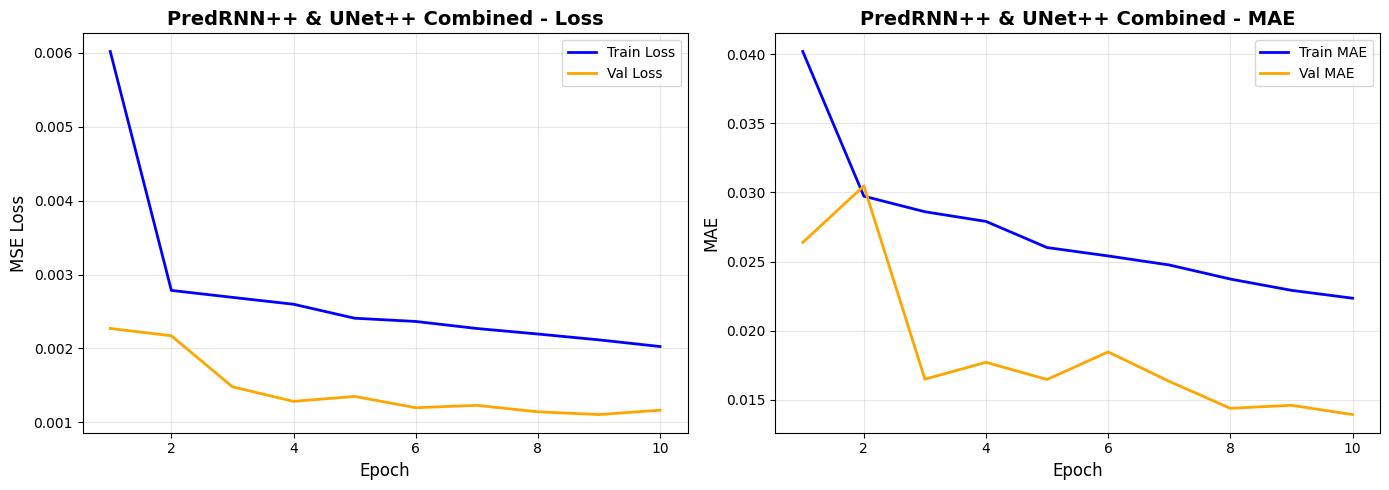

In [10]:
# ==================== VISUALIZATION ====================


def plot_training_history(history, title, save_path=None):
    """Plot training and validation curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    axes[0].plot(
        epochs, history["train_loss"], label="Train Loss", linewidth=2, color="blue"
    )
    axes[0].plot(
        epochs, history["val_loss"], label="Val Loss", linewidth=2, color="orange"
    )
    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_ylabel("MSE Loss", fontsize=12)
    axes[0].set_title(f"{title} - Loss", fontsize=14, fontweight="bold")
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # MAE
    axes[1].plot(
        epochs, history["train_mae"], label="Train MAE", linewidth=2, color="blue"
    )
    axes[1].plot(
        epochs, history["val_mae"], label="Val MAE", linewidth=2, color="orange"
    )
    axes[1].set_xlabel("Epoch", fontsize=12)
    axes[1].set_ylabel("MAE", fontsize=12)
    axes[1].set_title(f"{title} - MAE", fontsize=14, fontweight="bold")
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        logger.info(f"📊 Plot saved to {save_path}")
    plt.show()


# Plot training history
plot_training_history(
    history,
    "PredRNN++ & UNet++ Combined",
    config.LOG_DIR / f"{config.MODEL_NAME}_{config.VERSION}_training.png",
)


## 10. Evaluation on Test Set


In [11]:
# ==================== EVALUATION ====================


def evaluate_model(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    criterion = nn.MSELoss()

    total_loss = 0.0
    total_mae = 0.0
    all_preds = []
    all_targets = []

    logger.info("🔍 Evaluating on test set...")

    with torch.no_grad():
        for inputs, targets in tqdm(test_loader, desc="Testing", ncols=100):
            inputs = inputs.to(device)
            targets = targets.to(device)  # Already (B, 14, 1, H, W)

            outputs = model(inputs)

            loss = criterion(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))

            total_loss += loss.item()
            total_mae += mae.item()

            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    avg_loss = total_loss / len(test_loader)
    avg_mae = total_mae / len(test_loader)

    logger.info(f"📊 Test Results:")
    logger.info(f"   MSE Loss: {avg_loss:.6f}")
    logger.info(f"   MAE: {avg_mae:.6f}")

    return {
        "mse": avg_loss,
        "mae": avg_mae,
        "predictions": np.concatenate(all_preds, axis=0),
        "targets": np.concatenate(all_targets, axis=0),
    }


# Load best model
logger.info("📂 Loading best model for evaluation...")
checkpoint.load(model, load_best=True)

# Evaluate
test_results = evaluate_model(model, test_loader, config.DEVICE)

# Summary
print("\n" + "=" * 60)
print("📊 TEST EVALUATION RESULTS")
print("=" * 60)
print(f"\n{'Metric':<15} {'Value':<15}")
print("-" * 30)
print(f"{'MSE Loss':<15} {test_results['mse']:<15.6f}")
print(f"{'MAE':<15} {test_results['mae']:<15.6f}")
print("=" * 60)


2025-12-07 00:10:15 | INFO | 📂 Loading best model for evaluation...
2025-12-07 00:10:15 | INFO | 📂 Loaded model from ../../models/PredRNNpp_UNetpp_timeout_1_v1.0.0_best.pth
2025-12-07 00:10:15 | INFO | 🔍 Evaluating on test set...
Testing:   0%|                                                               | 0/39 [00:00<?, ?it/s]2025-12-07 00:10:15 | INFO | 📂 Loaded model from ../../models/PredRNNpp_UNetpp_timeout_1_v1.0.0_best.pth
2025-12-07 00:10:15 | INFO | 🔍 Evaluating on test set...
Testing: 100%|██████████████████████████████████████████████████████| 39/39 [00:10<00:00,  3.56it/s]
2025-12-07 00:10:26 | INFO | 📊 Test Results:
2025-12-07 00:10:26 | INFO |    MSE Loss: 0.003327
2025-12-07 00:10:26 | INFO |    MAE: 0.030439



📊 TEST EVALUATION RESULTS

Metric          Value          
------------------------------
MSE Loss        0.003327       
MAE             0.030439       


2025-12-07 00:13:57 | INFO | 📊 Visualizing predictions: shape = (154, 1, 1, 35, 35)
2025-12-07 00:13:58 | INFO | 🖼️ Predictions saved to ../../logs/PredRNNpp_UNetpp_timeout_1_v1.0.0_predictions.png
2025-12-07 00:13:58 | INFO | 🖼️ Predictions saved to ../../logs/PredRNNpp_UNetpp_timeout_1_v1.0.0_predictions.png


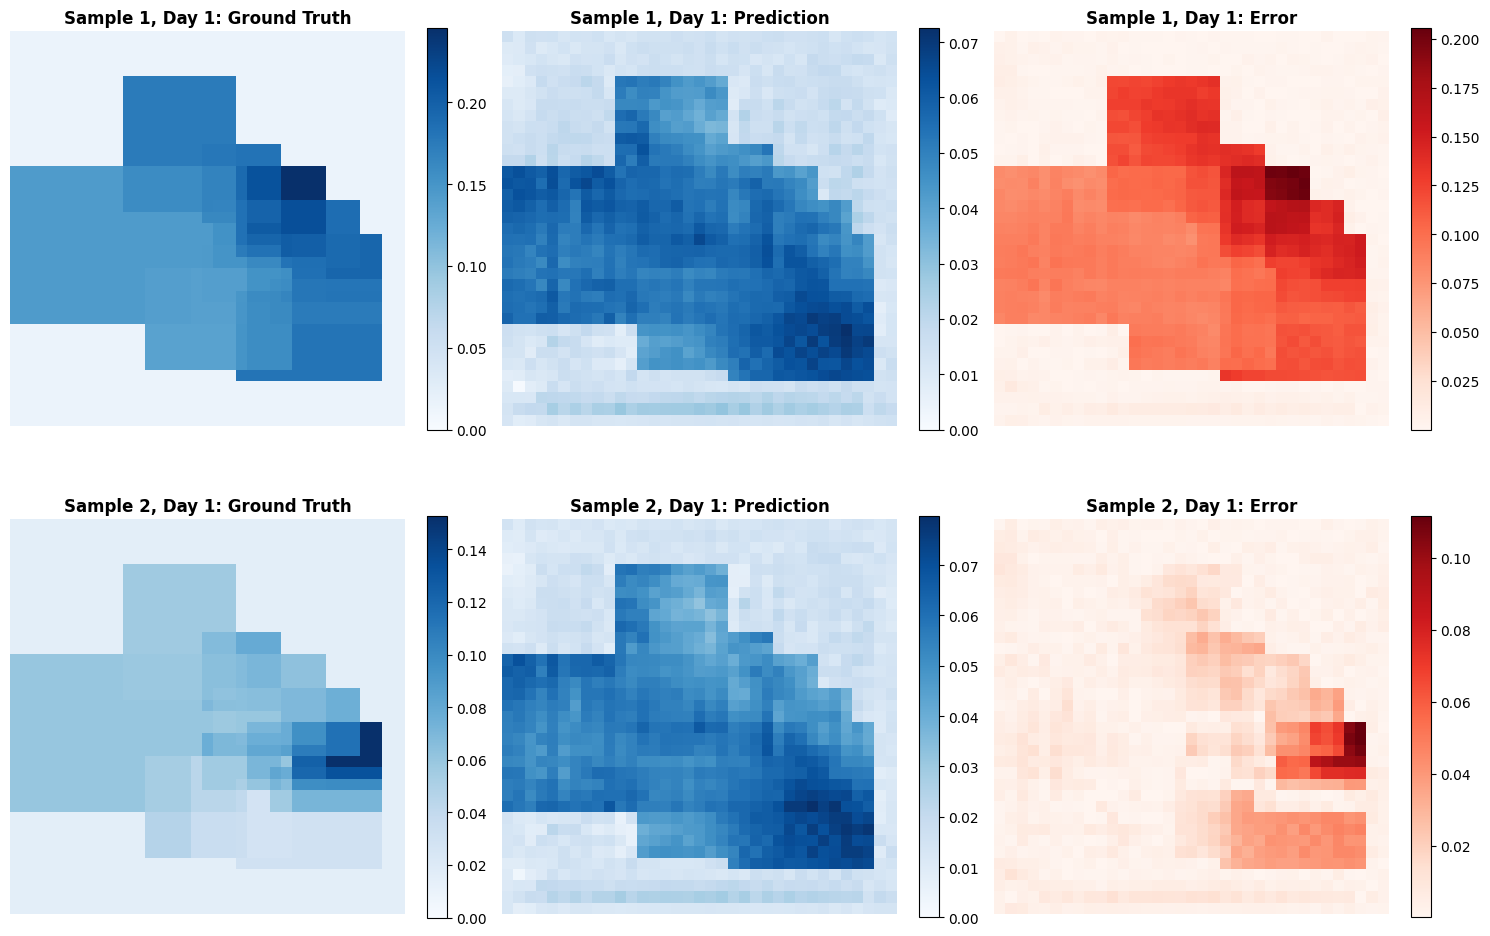

In [13]:
# ==================== VISUALIZE PREDICTIONS ====================


def visualize_predictions(
    predictions, targets, num_samples=3, num_days=None, save_path=None
):
    """
    Visualize prediction vs ground truth for multiple samples and days

    Args:
        predictions: (N, T, 1, H, W)
        targets: (N, T, 1, H, W)
        num_samples: Number of samples to visualize
        num_days: Number of days to visualize (None = all available days)
    """
    # Auto-detect num_days if not provided
    if num_days is None:
        num_days = min(predictions.shape[1], targets.shape[1])
    
    # Validate num_days
    max_days = min(predictions.shape[1], targets.shape[1])
    if num_days > max_days:
        logger.warning(f"⚠️ Requested {num_days} days but only {max_days} available. Using {max_days}.")
        num_days = max_days
    
    # Validate num_samples
    max_samples = min(predictions.shape[0], targets.shape[0])
    if num_samples > max_samples:
        logger.warning(f"⚠️ Requested {num_samples} samples but only {max_samples} available. Using {max_samples}.")
        num_samples = max_samples
    
    fig, axes = plt.subplots(
        num_samples, num_days * 3, figsize=(5 * num_days * 3, 5 * num_samples)
    )

    if num_samples == 1:
        axes = axes.reshape(1, -1)
    if num_days == 1:
        axes = axes.reshape(num_samples, -1)

    for i in range(num_samples):
        for d in range(num_days):
            col_offset = d * 3

            pred = predictions[i, d, 0]  # (H, W)
            target = targets[i, d, 0]  # (H, W)
            diff = np.abs(pred - target)

            # Ground Truth
            im1 = axes[i, col_offset].imshow(target, cmap="Blues", vmin=0)
            axes[i, col_offset].set_title(
                f"Sample {i+1}, Day {d+1}: Ground Truth", fontweight="bold"
            )
            axes[i, col_offset].axis("off")
            plt.colorbar(im1, ax=axes[i, col_offset], fraction=0.046)

            # Prediction
            im2 = axes[i, col_offset + 1].imshow(pred, cmap="Blues", vmin=0)
            axes[i, col_offset + 1].set_title(
                f"Sample {i+1}, Day {d+1}: Prediction", fontweight="bold"
            )
            axes[i, col_offset + 1].axis("off")
            plt.colorbar(im2, ax=axes[i, col_offset + 1], fraction=0.046)

            # Error
            im3 = axes[i, col_offset + 2].imshow(diff, cmap="Reds")
            axes[i, col_offset + 2].set_title(
                f"Sample {i+1}, Day {d+1}: Error", fontweight="bold"
            )
            axes[i, col_offset + 2].axis("off")
            plt.colorbar(im3, ax=axes[i, col_offset + 2], fraction=0.046)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        logger.info(f"🖼️ Predictions saved to {save_path}")
    plt.show()


# Visualize predictions (auto-detect num_days from data)
logger.info(f"📊 Visualizing predictions: shape = {test_results['predictions'].shape}")
visualize_predictions(
    test_results["predictions"],
    test_results["targets"],
    num_samples=2,
    num_days=None,  # Auto-detect: will use 1 day for time_out=1
    save_path=config.LOG_DIR / f"{config.MODEL_NAME}_{config.VERSION}_predictions.png",
)


## 11. Inference Pipeline

Pipeline cho inference trên dữ liệu mới.


2025-12-07 00:16:04 | INFO | ✅ Inference pipeline created
2025-12-07 00:16:04 | INFO |    Input shape: [30, 24, 35, 35]
2025-12-07 00:16:04 | INFO |    Output shape: [1, 35, 35]
2025-12-07 00:16:04 | INFO |    Prediction days: 1
2025-12-07 00:16:04 | INFO |    Input shape: [30, 24, 35, 35]
2025-12-07 00:16:04 | INFO |    Output shape: [1, 35, 35]
2025-12-07 00:16:04 | INFO |    Prediction days: 1


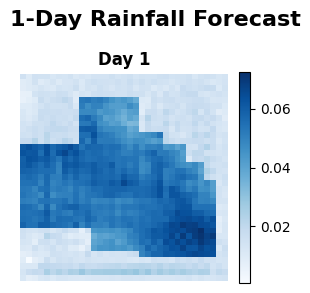

In [16]:
# ==================== INFERENCE PIPELINE ====================


class RainfallPredictionPipeline:
    """
    Inference pipeline for rainfall prediction

    Usage:
        pipeline = RainfallPredictionPipeline(model, device)
        predictions = pipeline.predict(input_sequence)
    """

    def __init__(self, model, device="cuda"):
        self.model = model
        self.device = device
        self.model.eval()

    def predict(self, input_sequence):
        """
        Predict rainfall for the next time_out days

        Args:
            input_sequence: (1, 30, 24, H, W) or (30, 24, H, W)

        Returns:
            predictions: (time_out, H, W) - Rainfall predictions
        """
        # Add batch dimension if needed
        if len(input_sequence.shape) == 4:
            input_sequence = input_sequence.unsqueeze(0)

        # Move to device
        if isinstance(input_sequence, np.ndarray):
            input_sequence = torch.FloatTensor(input_sequence)
        input_sequence = input_sequence.to(self.device)

        # Predict
        with torch.no_grad():
            output = self.model(input_sequence)  # (1, time_out, 1, H, W)

        # Return as numpy array
        predictions = output.squeeze(0).squeeze(1).cpu().numpy()  # (time_out, H, W)

        return predictions

    def predict_with_uncertainty(self, input_sequence, n_samples=10):
        """
        Predict with Monte Carlo Dropout for uncertainty estimation

        Note: Requires dropout layers to be active during inference
        """
        self.model.train()  # Enable dropout

        predictions = []
        for _ in range(n_samples):
            pred = self.predict(input_sequence)
            predictions.append(pred)

        self.model.eval()

        predictions = np.stack(predictions, axis=0)
        mean_pred = predictions.mean(axis=0)
        std_pred = predictions.std(axis=0)

        return mean_pred, std_pred


# Create inference pipeline
pipeline = RainfallPredictionPipeline(model, config.DEVICE)

# Test inference
sample_x, _ = next(iter(test_loader))
predictions = pipeline.predict(sample_x[0])

logger.info(f"✅ Inference pipeline created")
logger.info(f"   Input shape: {list(sample_x[0].shape)}")
logger.info(f"   Output shape: {list(predictions.shape)}")
logger.info(f"   Prediction days: {predictions.shape[0]}")

# Visualize forecast (auto-adjust grid based on num_days)
num_days = predictions.shape[0]  # Auto-detect from predictions

# Calculate grid layout
if num_days == 1:
    rows, cols = 1, 1
elif num_days <= 7:
    rows, cols = 1, num_days
else:
    rows = (num_days + 6) // 7  # Ceiling division
    cols = 7

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

# Flatten axes for easier indexing
if num_days == 1:
    axes = np.array([axes])
elif rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot predictions
for day in range(num_days):
    ax = axes_flat[day]
    im = ax.imshow(predictions[day], cmap="Blues")
    ax.set_title(f"Day {day+1}", fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

# Hide extra subplots
for day in range(num_days, len(axes_flat)):
    axes_flat[day].axis("off")

plt.suptitle(f"{num_days}-Day Rainfall Forecast", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(
    config.LOG_DIR / f"{config.MODEL_NAME}_{config.VERSION}_{num_days}day_forecast.png", dpi=300
)
plt.show()


## 12. Save Final Summary & Model


In [17]:
# ==================== FINAL SUMMARY ====================

# Count parameters
predrnn_params = sum(p.numel() for p in model.predrnn.parameters())
unetpp_params = sum(p.numel() for p in model.unetpp.parameters())
total_params = sum(p.numel() for p in model.parameters())

# Save complete model info
final_summary = {
    "model_name": config.MODEL_NAME,
    "version": config.VERSION,
    "timestamp": TIMESTAMP,
    "device": config.DEVICE,
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "architecture": {
        "description": "Combined PredRNN++ (Official) + UNet++ (Official)",
        "training_flow": "Input -> PredRNN++ -> UNet++ -> Output -> Loss -> Backward",
        "note": "Single backward pass updates both models (joint training)",
    },
    "data_config": {
        "time_in": config.TIME_IN,
        "time_out": config.TIME_OUT,
        "in_channels": config.IN_CHANNELS,
        "out_channels": config.OUT_CHANNELS,
        "height": config.HEIGHT,
        "width": config.WIDTH,
        "input_shape": f"(B, {config.TIME_IN}, {config.IN_CHANNELS}, {config.HEIGHT}, {config.WIDTH})",
        "output_shape": f"(B, {config.TIME_OUT}, {config.OUT_CHANNELS}, {config.HEIGHT}, {config.WIDTH})",
    },
    "predrnn_config": {
        "based_on": "github.com/thuml/predrnn-pytorch (Official)",
        "num_layers": config.PREDRNN_NUM_LAYERS,
        "num_hidden": config.PREDRNN_NUM_HIDDEN,
        "filter_size": config.PREDRNN_FILTER_SIZE,
        "layer_norm": config.PREDRNN_LAYER_NORM,
        "forget_bias": 1.0,
        "gate_computation": "Additive (i_t = sigmoid(i_x + i_h))",
        "memory_flow": "Zigzag (M flows from last layer t-1 to first layer t)",
        "total_params": predrnn_params,
    },
    "unetpp_config": {
        "based_on": "github.com/MrGiovanni/UNetPlusPlus (Official)",
        "features": config.UNETPP_FEATURES,
        "skip_connections": "Dense nested (X[i,j] = f(concat(X[i,0:j], Up(X[i+1,j-1]))))",
        "deep_supervision": config.UNETPP_DEEP_SUPERVISION,
        "total_params": unetpp_params,
    },
    "training_config": {
        "batch_size": config.BATCH_SIZE,
        "epochs": config.EPOCHS,
        "learning_rate": config.LEARNING_RATE,
        "weight_decay": config.WEIGHT_DECAY,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingWarmRestarts",
        "epochs_trained": len(history["train_loss"]),
        "best_val_loss": min(history["val_loss"]),
        "best_val_mae": min(history["val_mae"]),
    },
    "test_results": {"mse": test_results["mse"], "mae": test_results["mae"]},
    "total_params": total_params,
    "model_files": {
        "best": str(
            config.MODEL_DIR / f"{config.MODEL_NAME}_{config.VERSION}_best.pth"
        ),
        "latest": str(
            config.MODEL_DIR / f"{config.MODEL_NAME}_{config.VERSION}_latest.pth"
        ),
    },
    "log_files": {
        "training_log": str(LOG_FILE),
        "metrics": str(
            config.LOG_DIR / f"{config.MODEL_NAME}_{config.VERSION}_metrics.json"
        ),
    },
}

# Save summary
summary_path = config.LOG_DIR / f"{config.MODEL_NAME}_{config.VERSION}_summary.json"
with open(summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

logger.info("=" * 60)
logger.info("🎉 TRAINING COMPLETED SUCCESSFULLY!")
logger.info("=" * 60)
logger.info(f"📁 Model files saved to: {config.MODEL_DIR}")
logger.info(f"📁 Log files saved to: {config.LOG_DIR}")
logger.info(f"📄 Summary: {summary_path}")
logger.info("=" * 60)

# Print final summary
print("\n" + "=" * 70)
print("🎉 TRAINING COMPLETED - FINAL SUMMARY")
print("=" * 70)
print(f"\n📦 Model: {config.MODEL_NAME} {config.VERSION}")
print(
    f"🖥️  Device: {config.DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})"
)

print(f"\n📐 Architecture (theo CS313-data-mining README):")
print(
    f"   Input:  (B, {config.TIME_IN}, {config.IN_CHANNELS}, {config.HEIGHT}, {config.WIDTH})"
)
print(
    f"   Model 1 (PredRNN++): → (B, {config.TIME_OUT}, {config.IN_CHANNELS}, {config.HEIGHT}, {config.WIDTH})"
)
print(
    f"   Model 2 (UNet++):    → (B, {config.TIME_OUT}, {config.OUT_CHANNELS}, {config.HEIGHT}, {config.WIDTH})"
)
print(f"   Training: Forward both models → Single backward")

print(f"\n📊 PredRNN++ (Official Implementation):")
print(f"   - Based on: github.com/thuml/predrnn-pytorch")
print(f"   - Gate computation: Additive (NOT concat)")
print(f"   - Forget bias: 1.0")
print(f"   - Memory flow: Zigzag")
print(f"   - Parameters: {predrnn_params:,}")

print(f"\n📊 UNet++ (Official Implementation):")
print(f"   - Based on: github.com/MrGiovanni/UNetPlusPlus")
print(f"   - Skip connections: Dense nested")
print(f"   - Parameters: {unetpp_params:,}")

print(f"\n📊 Training Results:")
print(f"   - Epochs trained: {len(history['train_loss'])}")
print(f"   - Best Val Loss: {min(history['val_loss']):.6f}")
print(f"   - Best Val MAE: {min(history['val_mae']):.6f}")

print(f"\n📊 Test Results:")
print(f"   - Test MSE: {test_results['mse']:.6f}")
print(f"   - Test MAE: {test_results['mae']:.6f}")

print(f"\n📁 Saved Files:")
print(f"   - Model: {config.MODEL_NAME}_{config.VERSION}_best.pth")
print(f"   - Log: {LOG_FILE.name}")
print(f"   - Summary: {summary_path.name}")
print("=" * 70)


2025-12-07 00:16:05 | INFO | ============================================================
2025-12-07 00:16:05 | INFO | 🎉 TRAINING COMPLETED SUCCESSFULLY!
2025-12-07 00:16:05 | INFO | ============================================================
2025-12-07 00:16:05 | INFO | 📁 Model files saved to: ../../models
2025-12-07 00:16:05 | INFO | 📁 Log files saved to: ../../logs
2025-12-07 00:16:05 | INFO | 📄 Summary: ../../logs/PredRNNpp_UNetpp_timeout_1_v1.0.0_summary.json
2025-12-07 00:16:05 | INFO | ============================================================



🎉 TRAINING COMPLETED - FINAL SUMMARY

📦 Model: PredRNNpp_UNetpp_timeout_1 v1.0.0
🖥️  Device: cuda (NVIDIA GeForce RTX 5070 Ti)

📐 Architecture (theo CS313-data-mining README):
   Input:  (B, 30, 24, 35, 35)
   Model 1 (PredRNN++): → (B, 1, 24, 35, 35)
   Model 2 (UNet++):    → (B, 1, 1, 35, 35)
   Training: Forward both models → Single backward

📊 PredRNN++ (Official Implementation):
   - Based on: github.com/thuml/predrnn-pytorch
   - Gate computation: Additive (NOT concat)
   - Forget bias: 1.0
   - Memory flow: Zigzag
   - Parameters: 15,547,904

📊 UNet++ (Official Implementation):
   - Based on: github.com/MrGiovanni/UNetPlusPlus
   - Skip connections: Dense nested
   - Parameters: 9,051,873

📊 Training Results:
   - Epochs trained: 10
   - Best Val Loss: 0.001106
   - Best Val MAE: 0.013946

📊 Test Results:
   - Test MSE: 0.003327
   - Test MAE: 0.030439

📁 Saved Files:
   - Model: PredRNNpp_UNetpp_timeout_1_v1.0.0_best.pth
   - Log: PredRNNpp_UNetpp_timeout_1_20251206_232034.log